# Calibration curve

In [1]:
import pickle

import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

CLASS_NAMES = [
    "Type 0",
    "Type 1a",
    "Type 1b",
    "Type 2a",
    "Type 2b",
    "Type 3a",
    "Type 3b",
]
N_BINS = 5

In [2]:
y = pd.read_csv("../_temp/labels.csv")

In [3]:
all_y_prob = {}
methods = []
for path in [
    "../_temp/CV.sigmoid.pkl",
    "../_temp/CV.isotonic.pkl",
    "../_temp/CV.sigmoid_ovo.pkl",
    "../_temp/CV.isotonic_ovo.pkl",
    "../_temp/CV.temperature.pkl",
]:
    with open(path, "rb") as f:
        data = pickle.load(f)
    method = data["method"]
    methods.append(method)
    all_y_prob[method] = data["y_prob_oof"]

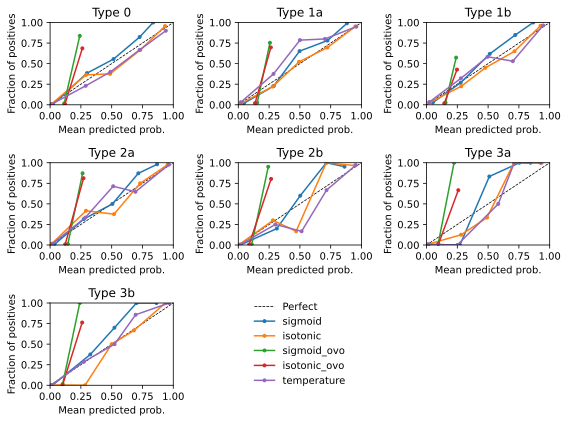

In [4]:
n_classes = next(iter(all_y_prob.values())).shape[1]
nrows = int(np.ceil(n_classes / 3))
ncols = min(n_classes, 3)
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 6))
axes_flat = axes.flatten()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for k in range(n_classes):
    ax = axes_flat[k]
    class_name = CLASS_NAMES[k] if k < len(CLASS_NAMES) else f"Class {k}"

    # Perfect calibration reference line
    ax.plot([0, 1], [0, 1], "k--", lw=0.75, label="Perfect")

    for i, method in enumerate(methods):
        y_prob_oof = all_y_prob[method]
        mask = ~np.isnan(y_prob_oof[:, k])
        frac_pos, mean_pred = calibration_curve(
            (y[mask] == class_name).astype(int),
            y_prob_oof[mask, k],
            n_bins=N_BINS,
            strategy="uniform",
        )

        ax.plot(
            mean_pred,
            frac_pos,
            marker=".",
            color=colors[i % len(colors)],
            label=method,
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(class_name)
    ax.set_xlabel("Mean predicted prob.")
    ax.set_ylabel("Fraction of positives")

# Hide unused axes
for k in range(n_classes, len(axes_flat)):
    axes_flat[k].set_visible(False)

# Single shared legend in the last (empty) panel or below the figure
if n_classes < len(axes_flat):
    legend_ax = axes_flat[n_classes]
    legend_ax.set_visible(True)
    legend_ax.axis("off")
    handles, labels = axes_flat[0].get_legend_handles_labels()
    legend_ax.legend(handles, labels, loc="center", frameon=False)
else:
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(methods) + 1,
        bbox_to_anchor=(0.5, -0.02),
        frameon=False,
    )
    fig.subplots_adjust(bottom=0.12)
plt.tight_layout()
plt.show()